In [307]:
# import Libraries 

In [308]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# import Datasets

In [309]:
df = pd.read_csv('/Users/apple/HousePricePrediction/data/train.csv')

In [310]:
df.head(4)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000


In [311]:
# for finding Missing values on Data

In [312]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [313]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [314]:
df["SalePrice"].head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [315]:
missing= df.isnull().sum()

In [316]:
missing[missing>0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [317]:
df.shape

(1460, 81)

In [318]:
# Find Missing value Analysis for Clean up data sets

In [319]:
missing_percentage= (df.isnull().sum()/len(df))*100
missing_percentage.sort_values(ascending=False).head(10)

PoolQC         99.520548
MiscFeature    96.301370
Alley          93.767123
Fence          80.753425
MasVnrType     59.726027
FireplaceQu    47.260274
LotFrontage    17.739726
GarageYrBlt     5.547945
GarageCond      5.547945
GarageType      5.547945
dtype: float64

In [320]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [321]:
# Visualize target Variable

In [322]:
corr = df.corr(numeric_only=True)

corr["SalePrice"].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [323]:
# Data cleaning By Dropping Empy Data

In [324]:
df_clean =df.copy()
cols_to_drop = [
    'PoolQC',
    'MiscFeature',
    'Alley',
    'Fence'
]

df_clean.drop(columns= cols_to_drop, inplace= True)
df_clean.shape

(1460, 77)

In [325]:
missing_percentage = (
    df_clean.isnull().sum() / len(df_clean)
) * 100

missing_percentage[missing_percentage > 0].sort_values(
    ascending=False
).head(20)

MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [326]:
# find all categorical columns

In [327]:
df_clean.select_dtypes(include=['object']).columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [328]:
# find all numerical columns

In [329]:
df_clean.select_dtypes(exclude=['object']).columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [330]:
# Fill missing values in numercial columnns

In [331]:
num_cols = df_clean.select_dtypes(exclude=['object']).columns

for col in num_cols:
    df_clean[col].fillna(
        df_clean[col].median(),
        inplace=True
    )

/var/folders/lq/n2dxsxc55_17wj737vn6276w0000gn/T/ipykernel_22014/4094479398.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(


In [332]:
# Fill missing values in categorical columnns

In [333]:
cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_clean[col].fillna(
        df_clean[col].mode()[0],
        inplace=True
    )

/var/folders/lq/n2dxsxc55_17wj737vn6276w0000gn/T/ipykernel_22014/3514559108.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(


In [334]:
#verify missing values gone or not

In [335]:
df_clean.isnull().sum().sum()

np.int64(0)

In [336]:
# Split training and test Data
# x represent features that is input
# y represent targer that is output.
# df_clean is the cleaned data sets that achieved after cleaning and filling missing values

In [337]:
X = df_clean.drop("SalePrice", axis=1)
y = df_clean["SalePrice"]

In [338]:
# Convert Categorical Columns to Numbers i.e Adding Encoding

In [339]:
X = pd.get_dummies(X, drop_first=True)

In [340]:
X.shape

(1460, 236)

In [341]:
#Train-Test Split
# Giving 20% for Test 

In [342]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state= 42,
    
)

In [343]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1168, 236)
(292, 236)
(1168,)
(292,)


In [344]:
# Train model on Linear refression Model

In [345]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [346]:
# Testing Prediction 
# Test First few predictions

In [347]:
predictions = model.predict(X_test)

In [348]:
predictions[:10]

array([155938.41042558, 352300.00992554,  89640.30702609, 174631.19070086,
       321755.05175991,  66177.61488861, 233101.78149836, 147426.86211238,
        57348.01570895, 147534.70815784])

In [349]:
# Evaluation Model is good or not.

In [350]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = mse ** 0.5

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 20436.780806452112
RMSE: 52315.52434719284
R2 Score: 0.6431815266008859


In [351]:
# Linear Regression model is not good, as it gives a lots of MSE error.
# So now we are going to include Random forest model.
# For random forest

In [352]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [353]:
rf_predictions = rf_model.predict(X_test)

In [354]:
# For not to retrain model every model a job lib for random forest model created

In [355]:
import joblib

joblib.dump(
    rf_model,
    'house_price_model.pkl'
)

['house_price_model.pkl']

In [356]:
# Verifying the Regression file is created successfully

In [357]:
loaded_model = joblib.load(
    'house_price_model.pkl'
)

loaded_model

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [358]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = mean_squared_error(
    y_test,
    rf_predictions
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("RF MAE:", rf_mae)
print("RF RMSE:", rf_rmse)
print("RF R2:", rf_r2)

RF MAE: 17675.421712328767
RF RMSE: 28833.017568806998
RF R2: 0.8916157045127805


In [359]:
# Finding which features/Inputs has a biggest impact on hour price prediction?

In [360]:
feature_importance = pd.DataFrame ({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by= 'Importance',
    ascending= False
)
feature_importance.head(10)

,Feature,Importance
4,OverallQual,0.557309
16,GrLivArea,0.120578
14,2ndFlrSF,0.034510
12,TotalBsmtSF,0.034165
9,BsmtFinSF1,0.029233
13,1stFlrSF,0.026236
3,LotArea,0.017377
27,GarageArea,0.016348
26,GarageCars,0.012328
6,YearBuilt,0.011274


In [361]:
# Visualize features/input biggest impact list.

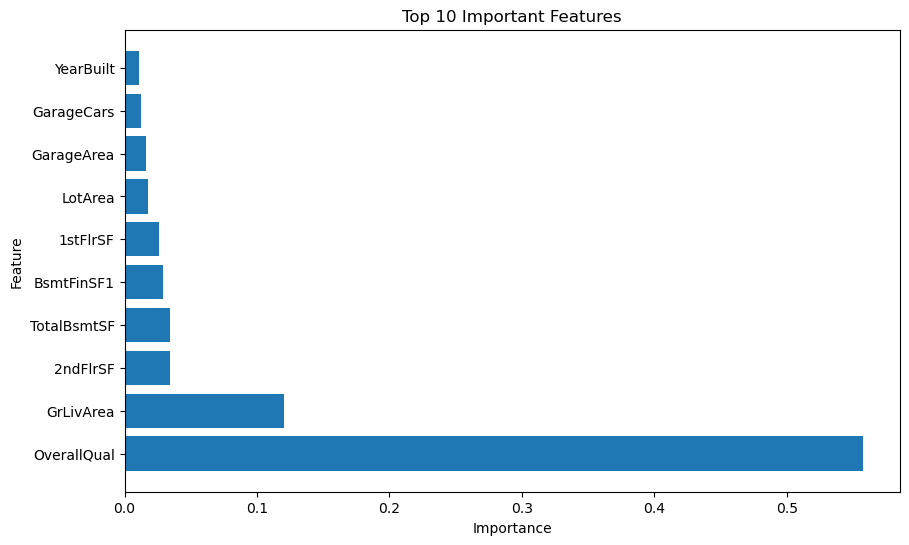

In [362]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')

plt.show()

In [363]:
# Verify the accuracy Score using cross validation, It will help us to make decison on the model is working fine with the split 
# of 80% train and 20% text or vice-versa
# from sklearn.model_selection import cross_val_score

In [364]:
scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)

[0.87110687 0.83994334 0.87145618 0.88152241 0.80774538]


In [365]:
print("Average R2:", scores.mean())

Average R2: 0.8543548370351118


In [ ]:
#Model Comparison 

In [366]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'R2': [
        0.643,
        0.892
    ]
})

results

,Model,R2
0,Linear Regression,0.643
1,Random Forest,0.892
